<a href="https://colab.research.google.com/github/classicemmaeasy/AI-Hacktober-MLSA/blob/main/NNotebooks/T8_torch_NN_pipeline_and_questions_for_assign_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pipeline for deep learning with PyTorch**

## Major steps from data to deployment

| Step                | Key Actions                                                                | Main PyTorch Classes/Methods                  |
|---------------------|----------------------------------------------------------------------------|-----------------------------------------------|
| Data Preparation    | Load, transform, batch, and split data                                     | `torch.utils.data.Dataset`, `DataLoader`, `torchvision.transforms`  |
| Model Development   | Define architecture, choose loss/optimizer, set hyperparameters            | `torch.nn.Module`, `torch.nn.Parameter`, `torch.nn.functional`, `torch.optim` |
| Model Training      | Forward pass, loss computation, backward pass, parameter update, epochs    | `forward()`, `loss.backward()`, `optimizer.step()`, `optimizer.zero_grad()` , `model.train()` |
| Validation          | Evaluate on validation set, compute metrics, tune hyperparameters          | `model.eval()`, `torch.no_grad()`, metric functions (e.g., `torchmetrics`) |
| Testing/Deployment  | Final evaluation on test set, save and deploy model                        | `torch.save()`, `torch.load()`, `model.eval()`, `torch.jit` |

## Typical training loop.

Recall that the whole set of examples is visited during one epoch. Moreover, the *dataloader* groups examples in batches, and defines some other functionalities like shuffling the examples each time the iterator is created with `for inputs, targets in dataloader` in the example below.

For standard neural network training in PyTorch, inputs and targets should be tensors. This can be dealt with in the *data preparation* step, using `transforms` when creating the custom `Dataset` class for the problem at hand (see https://github.com/isa-ulisboa/greends-pml/blob/main/notebooks/T6_pytorch_dataset_dataloader.ipynb).

As discussed in https://github.com/isa-ulisboa/greends-pml/blob/main/docs/T1_basic_concepts.md for a simple linear regression problem, PyTorch uses **backpropagation** as the strategy to updates the model weights for loss minimization. The exact same idea can be generalized to multilayer neural networks and deep-learning.

The typical training loop in PyTorch is described in the code below.
1. The forward pass is done with `model(inputs)` that applies the model to the input and computes the output. This is a probability distribution over the possible labels.
2. The backward pass is done with `optimizer.step()` using the gradient computed with `loss.backward()`. The loss, as always, depends on the actual output `target` and the predicted output `outputs`. The line of code `optimizer.zero_grad()` prevents the gradients to be summed up along the process. For  backpropagation to work, the model must be in training mode, which it is set by default or by setting `model.train()`.

  ```
  for epoch in range(num_epochs):
      for inputs, targets in dataloader:
          optimizer.zero_grad()
          outputs = model(inputs)
          loss = criterion(outputs, targets)
          loss.backward()
          optimizer.step()
  ```

## Example for data preparation and model training: the MNIST data set

### Step 1: Data preparation

In [5]:
!pip install torchvision

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

In [6]:
# Define a transformation to flatten the 8x8 images
transform = transforms.Compose([
    transforms.Resize((8, 8)),         # Resize the PIL Image to 8x8 first (MNIST images are originally 28x28)
    transforms.ToTensor(),             # Then convert to tensor
    transforms.Lambda(lambda x: x.view(-1))  # Finally, flatten the tensor
])

# Load the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.71MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]


**Question**. Dataloaders `train_loader` and `test_loader` are iterators which allow to access examples and labels.
- What is the type of objects yielded by the train and test dataloaders?
- What is the *shape* of `images` returned by `for images, labels in train_loader`? How do you interpret that shape?
- Why dataloaders for train and test differ with respect to the option `shuffle`?

### What is the type of objects yielded by the train and test dataloaders?


The train_loader (and similarly the test_loader) yields batches of images and labels,both of which are torch.Tensor objects.

In [7]:
# Prompt: Generate the code to get the type of objects yielded by the train and test dataloaders?

for images, labels in train_loader:
    print(f"Type of images: {type(images)}")
    print(f"Type of labels: {type(labels)}")
    break


Type of images: <class 'torch.Tensor'>
Type of labels: <class 'torch.Tensor'>


### What is the shape of images returned by for images, labels in train_loader? How do you interpret that shape?

In [8]:
for images, labels in train_loader:
    print(f"Shape of images: {images.shape}")
    break

Shape of images: torch.Size([64, 64])


#The shuffle option in DataLoader is set differently for the training and test sets for specific reasons related to model training and evaluation:

train_loader (shuffle=True): For the training set, shuffle=True is crucial. It shuffles the data at the beginning of each epoch. This randomizes the order in which the model sees the data, which helps to:

Prevent overfitting: By presenting data in a different order each time, the model is less likely to memorize the specific sequence of training examples.
Improve generalization: Shuffling ensures that the model learns from a diverse set of examples in each batch, leading to more robust and generalized learning.
Avoid biases: If the data had an inherent order (e.g., all examples of one class followed by all examples of another), shuffling prevents the model from being biased towards the patterns seen early in an epoch.
test_loader (shuffle=False): For the test set (and typically for validation sets), shuffle=False is used. The primary reason for this is to ensure:

Reproducible and consistent evaluation: By not shuffling, the model is evaluated on the test set in the same fixed order every time. This makes the evaluation process deterministic and allows for consistent comparison of different models or training runs. If the test set were shuffled, small variations in the order could lead to slightly different reported metrics, making comparisons difficult.

The shape `torch.Size([64, 64])` means that for each batch:

*   **64**: This is the `batch_size`, indicating that there are 64 images in this batch.
*   **64**: This is the flattened size of each individual image. Since the original 8x8 images were flattened, each image is now represented as a 1D tensor of 64 pixels.

#### Visualize some examples and labels

Since the `transform` that was applied above returns flattened tensors, one needs to unflatten them to be able to create an image that can be plotted.

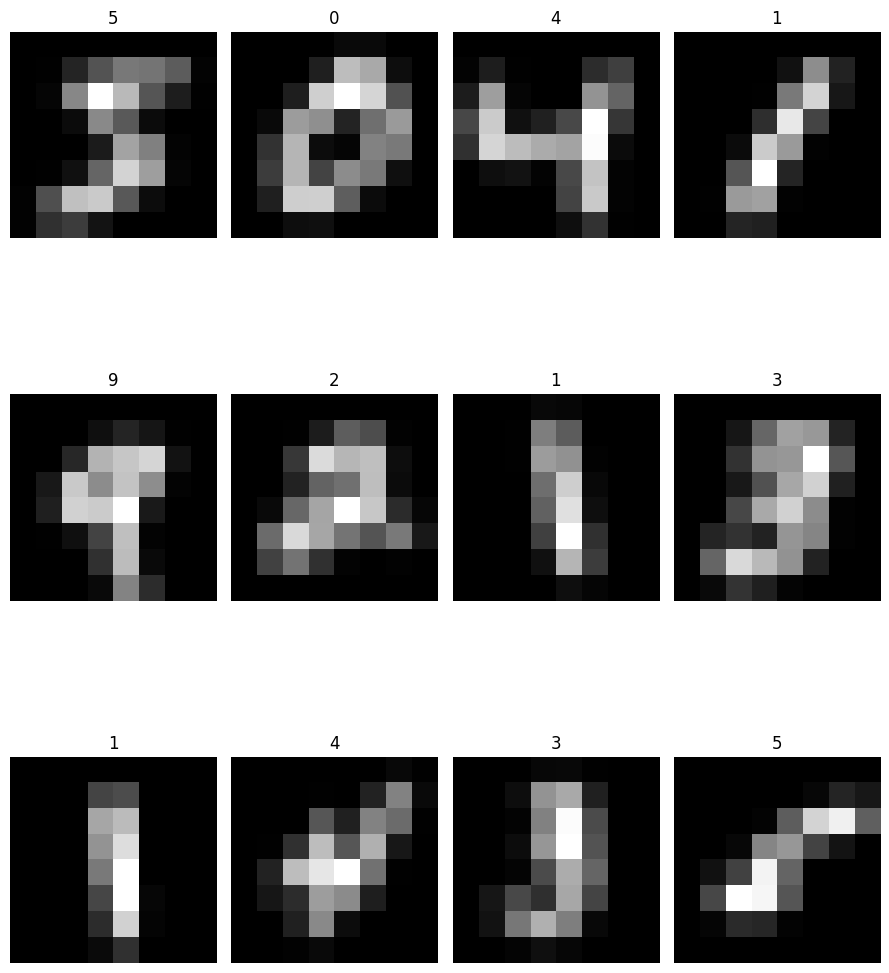

In [9]:
# Assuming each image is a 1D tensor of length 64 (8*8)
images, labels = zip(*[train_dataset[i] for i in range(12)]) # Visualize only the first 12 examples

fig, axes = plt.subplots(3, 4, figsize=(9, 12))
for i, ax in enumerate(axes.flat):
    img = images[i].reshape(8, 8)  # Unflatten to 2D
    ax.imshow(img, cmap='gray')
    ax.set_title(str(labels[i]), fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Step 2: model development

In [10]:
# Model Development: the model is a multilayer perceptron with one hidden layer
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Since we are using 8x8 MNIST and flatenning the input, the input size is 8 * 8 = 64
input_size = 8 * 8
hidden_size = 128
num_classes = 10 # 0-9 digits

model = SimpleNN(input_size, hidden_size, num_classes)

**Question**:
- The model architecture depends on the input data shape. The input images of MNIST are originally of size $28 \times 28$ but they have been resized to $8 \times 8$ pixels. Which changes do you need to do if you want to use the original $28 \times 28$ size? Indicate two changes you need to do in this notebook.
- Which change you need to do in the `SimpleNN` class if you want your model to have two hidden layers, both with size 128?
- What is a `ReLU` activation function called by `nn.ReLU`?
- Why are non linear activation functions like `ReLU` necessary for deep learning?

1.  **Modify the `transform`**: You would remove or change `transforms.Resize((8, 8))` to `transforms.Resize((28, 28))` (or simply remove it if the images are already 28x28). Crucially, the flattening step would need to account for the new size. The `transforms.Lambda(lambda x: x.view(-1))` would remain, but it would flatten a 28x28 image instead of an 8x8 image.

2.  **Update `input_size` in the `SimpleNN` model**: The `input_size` for the first fully connected layer (`fc1`) in your `SimpleNN` class needs to be changed from `8 * 8 = 64` to `28 * 28 = 784`.

The model architecture depends on the input data shape. The input images of MNIST are originally of size  28×28  but they have been resized to  8×8  pixels. Which changes do you need to do if you want to use the original  28×28  size? Indicate two changes you need to do in this notebook.

In [11]:
# Prompt: I want to resize to use the original 28×28 size, I need two key changes to be made
# to execute the code

# --- Change 1: Modified transform for 28x28 images ---
# Define a transformation for the original 28x28 images
# I removed transforms.Resize((8, 8)) and change it to (28, 28)
# - Assuming MNIST images are initially 28x28, I'll only need to convert to tensor and flatten

transform_28x28 = transforms.Compose([
    transforms.ToTensor(),             # Convert to tensor
    transforms.Lambda(lambda x: x.view(-1))  # Flatten the tensor (28*28 = 784 pixels)
])

# Load the MNIST dataset with the new transform
train_dataset_28x28 = datasets.MNIST(root='./data', train=True, download=True, transform=transform_28x28)
test_dataset_28x28 = datasets.MNIST(root='./data', train=False, download=True, transform=transform_28x28)

# Create DataLoaders with the new dataset
batch_size = 64 # Keep batch size same for comparison
train_loader_28x28 = DataLoader(train_dataset_28x28, batch_size=batch_size, shuffle=True)
test_loader_28x28 = DataLoader(test_dataset_28x28, batch_size=batch_size, shuffle=False)

print("New train_loader_28x28 and test_loader_28x28 created with 28x28 flattened images.")

# Let's verify the shape with the new loader
for images, labels in train_loader_28x28:
    print(f"Shape of images with 28x28: {images.shape}")
    break

New train_loader_28x28 and test_loader_28x28 created with 28x28 flattened images.
Shape of images with 28x28: torch.Size([64, 784])


In [12]:
# --- Change 2: Update input_size in the model ---
# Re-define the SimpleNN class with the updated input_size
class SimpleNN_28x28(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN_28x28, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Since we are using 28x28 MNIST and flattening the input, the input size is 28 * 28 = 784
input_size_28x28 = 28 * 28
hidden_size = 128 # Keeping hidden size same
num_classes = 10 # 0-9 digits

model_28x28 = SimpleNN_28x28(input_size_28x28, hidden_size, num_classes)

print(f"New model 'model_28x28' created with input_size = {input_size_28x28}")

New model 'model_28x28' created with input_size = 784


Which change you need to do in the SimpleNN class if you want your model to have two hidden layers, both with size 128?

To have two hidden layers, both with size 128, I would modify the SimpleNN class as follows:

Add a second fully connected layer (fc2) in the __init__ method, connecting the first hidden layer (size 128) to the second hidden layer (size 128).
Add another ReLU activation after the fc2 layer.
Rename the original fc2 to fc3 (or similar) to connect the second hidden layer to the output layer.

In [4]:

# Prompt:  Generate the code to change in the SimpleNN class to have two hidden layers,
# both with size 128

import torch.nn as nn

class SimpleNN_TwoHiddenLayers(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, num_classes):
        super(SimpleNN_TwoHiddenLayers, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1) # Input to first hidden layer
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2) # First hidden to second hidden layer
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size2, num_classes) # Second hidden to output layer

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        return out

# Example instantiation with two hidden layers of size 128 (using 28x28 image input_size):
input_size_for_two_hidden = 784 # Assuming 28x28 flattened images
hidden_size1 = 128
hidden_size2 = 128
num_classes = 10

model_two_hidden_layers = SimpleNN_TwoHiddenLayers(input_size_for_two_hidden, hidden_size1, hidden_size2, num_classes)

print(f"Model 'model_two_hidden_layers' created with two hidden layers of size {hidden_size1} and {hidden_size2}.")

Model 'model_two_hidden_layers' created with two hidden layers of size 128 and 128.


### What is a ReLU activation function called by nn.ReLU?


The ReLU activation function, called by nn.ReLU() in PyTorch, stands for Rectified Linear Unit.

Why it is necessary for Deep Learning:

Introducing Non-linearity: Without non-linear functions like ReLU, a neural network, no matter how many layers it has—would behave like a single linear model (since a linear combination of linear functions is still linear). Non-linearity allows the model to learn complex, non-linear patterns in data.
Efficiency:

ReLU is computationally very cheap to calculate compared to other functions like sigmoid or tanh because it only involves a simple thresholding at zero.
Reducing Vanishing Gradients: ReLU helps alleviate the 'vanishing gradient' problem during backpropagation, as its gradient is either 0 or 1, which helps gradients flow more effectively through deep layers of the network.



### Why are non linear activation functions like ReLU necessary for deep learning?



Non-linear activation functions like ReLU (Rectified Linear Unit) are fundamental to deep learning for several critical reasons:

Enabling Complex Pattern Learning: If a neural network only used linear activations (or no activation at all), the entire network, regardless of its depth, would collapse into a single linear transformation ($f(x) = Ax + b$$f(x) = Ax + b$). This is because a combination of linear functions is always a linear function. Non-linearity allows the model to learn and represent complex, non-linear relationships in data, such as those found in images, speech, and text.

Creating Deep Representations: Deep learning relies on building a hierarchy of features (e.g., in images, going from edges to shapes to objects). Non-linear functions act as 'gates' that allow the network to decide which information is important to pass forward, enabling it to learn abstract features that a linear model simply cannot capture.

Solving Non-Linearly Separable Problems: Most real-world classification tasks are not linearly separable (you cannot draw a straight line to separate classes). Activation functions allow the network to warp and fold the input space into a new representation where classes can be separated.

Universal Approximation: According to the Universal Approximation Theorem, a neural network with at least one hidden layer and a non-linear activation function can approximate any continuous function to any desired degree of accuracy. Without non-linearity, this capability is lost.

In [13]:
# Loss and optimizer: necessary for training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### Some details about cross entropy, softmax, one hot encoding and distributions

Since the problem is a *classification problem*, the criterion to compare model predictions with actual labels (what was denoted be $y$ and $\hat{y}$ for regression) is typically `criterion = nn.CrossEntropyLoss()`. This function has two arguments:
1. the output of the model (a list of scores returned by the model for each possible class, where the largest score corresponds to the most likely class) and
2. the target, which is the actual label of example. For instance if there are 10 classes $0, 1, \dots, 9$, the output would be a list like $[0.3,1.2,2.5,0.2,...]$ with 10 values, and the target could be 2 for instance.

The `nn.CrossEntropyLoss()` function will internally process the scores an the target the following way.

1. **Scores**. The unormalized model outputs $f_1, \dots, f_k$ are called *scores*, *logits* or *raw* outputs. Each score $z_i=f_i({\rm \bf x};{\rm \bf w_i})$ is converted into a [0,1] value by the *softmax* function:
$$p_i=\frac{\exp(z_i)}{\sum_{j=1}^k \exp(z_j)} ~~ {\rm which~implies~that} ~~ 0<p_i \le 1.$$
After that transformation, the classification model's probabilistic output is a vector of values $(p_1,\dots,p_k)$, with $p_i \ge 0$ and $\sum p_i=1$ as required for  probability distributions. The predicted label is the one with highest $p$.

<img src="https://drive.google.com/uc?export=view&id=1iD519g8QbBmOGp9SiOQsIneJnWg53SMQ" width="600" >


2. **Target**. A target value of, say, 2 is one-hot-encoded into the list $[0,0,1,0,...,0]$ of length 10.

The **cross-entropy loss** measures the dissimilarity between the probability distribution returned by *softmax* $(p_1,p_2,\dots)$ and the one hor encoded target distribution $(t_1,t_2,\dots)$ for each example. Its value range from 0 (optimal value associated to minimum uncertainty) and 1 (maximum value associated to maximum uncertainty, i.e. all probabilities are equal):

$$L_{single~example}=-\left( t_1 \, \log(p_1) + t_2 \, \log(p_2) + \dots \right) \in [0,1].$$

In the expression above, we suppose that the probabilities $p_i$ are non zero which is guaranteed by the *softmax* function.

For a batch of $n$ examples, the cross-entropy loss is given by the average of the $n$ individual loss values, where $L_i$ is the cross entropy for the $i$th example:

$$L_{batch}=\frac{1}{n} \left( L_1+L_2+ \dots,L_n\right).$$


### Step 3: Model training

In [14]:
# number of epochs
num_epochs = 3

#### Typical training loop

In [15]:
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


epoch: 1; time: 1779793309
epoch: 2; time: 1779793320
epoch: 3; time: 1779793330


**Question**. Does processing time decreases if you add the option `num_workers=2` when defining the dataloader? Compute training time with and without that option and show the results for comparison.




### My Approach
Comparing Training Time with and without num_workers

num_workers in DataLoader allows for parallel data loading, which can potentially speed up training by offloading data preparation to separate processes. I will compare the training time for 3 epochs with num_workers=0 (default, data loaded in the main process) and num_workers=2.

First, I need a reusable training function.

In [25]:
# Prompt: I want to add the option num_workers=2 when defining
# the dataloader and compute training time with and without that option
# and show the results for comparison.


import time
import torch.optim as optim
from torch.utils.data import DataLoader

# Re-using the SimpleNN class definition, device, criterion (nn.CrossEntropyLoss()),
# input_size, hidden_size, and num_classes from earlier in the notebook.

def train_model_and_measure_time(model_instance, train_loader, device, criterion, num_epochs=3):
    # Re-initialize optimizer inside to ensure a fresh state for each run
    optimizer = optim.Adam(model_instance.parameters(), lr=0.001)

    model_instance.to(device)
    start_time = time.time()
    for epoch in range(num_epochs):
        model_instance.train()
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model_instance(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    end_time = time.time()
    return end_time - start_time


#### 1. Training with `num_workers=0` (default)

In [26]:
# Create DataLoader without num_workers (default is 0)
batch_size = 64
train_loader_no_workers = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

# Create a new model instance for this test to ensure fair comparison
model_no_workers = SimpleNN(input_size, hidden_size, num_classes)

print("Starting training with num_workers=0...")
time_no_workers = train_model_and_measure_time(model_no_workers, train_loader_no_workers, device, criterion, num_epochs=3)
print(f"Training time with num_workers=0: {time_no_workers:.2f} seconds")


Starting training with num_workers=0...
Training time with num_workers=0: 31.15 seconds


#### 2. Training with `num_workers=2`

In [27]:
# Create DataLoader with num_workers=2
train_loader_with_workers = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

# Create another new model instance for this test
model_with_workers = SimpleNN(input_size, hidden_size, num_classes)

print("Starting training with num_workers=2...")
time_with_workers = train_model_and_measure_time(model_with_workers, train_loader_with_workers, device, criterion, num_epochs=3)
print(f"Training time with num_workers=2: {time_with_workers:.2f} seconds")


Starting training with num_workers=2...
Training time with num_workers=2: 31.50 seconds


#### 3. Comparison of Results

In [28]:
print(f"Time with num_workers=0: {time_no_workers:.2f} seconds")
print(f"Time with num_workers=2: {time_with_workers:.2f} seconds")

difference = time_no_workers - time_with_workers

if difference > 0:
    print(f"Using num_workers=2 resulted in faster training by {abs(difference):.2f} seconds.")
elif difference < 0:
    print(f"Using num_workers=2 resulted in slower training by {abs(difference):.2f} seconds.")
else:
    print("There was no significant change in training time with num_workers=2.")

print("\nInterpretation: The impact of num_workers can vary based on factors like CPU cores, I/O speed, and the complexity of data transformations. For simple datasets like MNIST, the overhead of creating worker processes might sometimes outweigh the benefits of parallel loading, especially for a small number of epochs or when training on a GPU that is the bottleneck. For more complex data pipelines or CPU-bound transformations, num_workers typically provides a significant speedup.")

Time with num_workers=0: 31.15 seconds
Time with num_workers=2: 31.50 seconds
Using num_workers=2 resulted in slower training by 0.35 seconds.

Interpretation: The impact of num_workers can vary based on factors like CPU cores, I/O speed, and the complexity of data transformations. For simple datasets like MNIST, the overhead of creating worker processes might sometimes outweigh the benefits of parallel loading, especially for a small number of epochs or when training on a GPU that is the bottleneck. For more complex data pipelines or CPU-bound transformations, num_workers typically provides a significant speedup.


#### Change device: run training on GPU

Training involves many large matrix computations. In general, this is done faster if it is parellelized over multiple cores. One can determine which device, either `cuda` (for GPU) or `cpu`, is used for training. Both model and data must be moved to the right device.

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device) #<<<<<<<<<< move model to device

# Re-initialize the optimizer after moving the model to the device
optimizer = optim.Adam(model.parameters(), lr=0.001)

#move data to GPU
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

Using device: cuda
epoch: 1; time: 1779793341
epoch: 2; time: 1779793351
epoch: 3; time: 1779793362


### Step 4: Validation

Validation is important for several goals, including:
- to estimate the accuracy of the model for the task at hand;
- to determine the optimal number of iterations (epochs);
- to be able to tune the model choosing the best hyperparameters.

Below, we will concentrate on the first two of those issues, and we will compare the estimated overall accuracy over the train and the test sets. In order to do this need to keep track of the intermediate results for each epoch and each batch of examples.

In [17]:
# Model Training
num_epochs = 5

# Computes the accuracy for a batch: outputs are probability-like values
def compute_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = len(labels)
    return correct / total

# History object to keep track of accuracy along epochs
history = {'epoch': [], 'train_accuracy': [], 'val_accuracy': []}

for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    batch_accuracies=[]
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # compute accuracy over the batch
        batch_accuracies.append(compute_accuracy(outputs, labels))
    history['epoch'].append(epoch)
    history['train_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

    # Validation phase
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.eval()
    batch_accuracies=[]
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)  #<<<<<<<<<< move data to device
            labels = labels.to(device)  #<<<<<<<<<< move data to device
            outputs = model(images)
            # compute accuracy over the batch
            batch_accuracies.append(compute_accuracy(outputs, labels))
        history['val_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

epoch: 1; time: 1779793372
epoch: 1; time: 1779793382
epoch: 2; time: 1779793383
epoch: 2; time: 1779793393
epoch: 3; time: 1779793395
epoch: 3; time: 1779793405
epoch: 4; time: 1779793406
epoch: 4; time: 1779793418
epoch: 5; time: 1779793421
epoch: 5; time: 1779793431


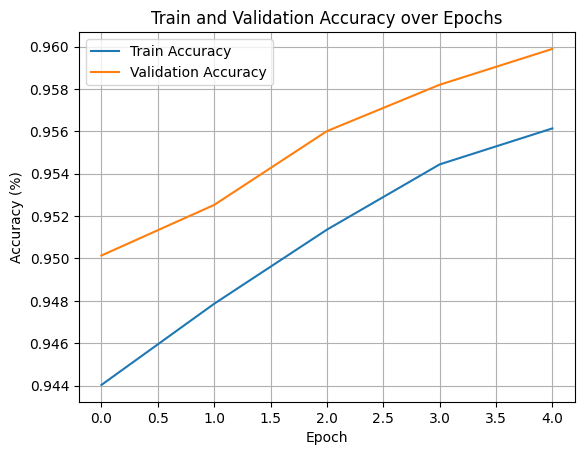

In [18]:
# accuracy plot
plt.plot(history['epoch'], history['train_accuracy'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

**Question**:
- From the visualization of that plot, do you think that 5 epochs are enough, or should the model train longer than that?
- Can you find a reason for the validation curve to be consistently higher than the training curve, which in principle should not happen. Hint: look at how the history for train and validation are computed during model training, and correct the plot construction.



Based on the plot where both training and validation accuracy curves are still showing an upward trend, it suggests that the model could potentially benefit from further training. The curves haven't fully plateaued, nor have they diverged significantly in a way that would clearly indicate overfitting (where training accuracy continues to rise while validation accuracy drops).

Therefore, it's likely that the model should train longer than 5 epochs to see if it can achieve even higher accuracy and to observe if the curves eventually stabilize or show clear signs of overfitting.

Yes, the reason for the validation curve being consistently higher than the training curve, which is an unusual pattern, is primarily due to how the training accuracy is calculated versus validation accuracy in the 0m9K5d8a6e0d cell.

Here's the breakdown of why this happens:

Training Accuracy Calculation (during training loop): The batch_accuracies for training are computed during each training batch, after the optimizer.step() call. This means the accuracy is being measured on a model whose weights have just been updated based on the current batch's loss. This can sometimes lead to an 'underestimation' of the overall training accuracy for the epoch, as the model is still in the process of learning and adjusting within that epoch.

Validation Accuracy Calculation (after epoch): In contrast, validation accuracy is typically computed after the entire training epoch has completed, using the model.eval() mode and torch.no_grad(). This means the validation accuracy is measured on the final, most updated state of the model for that epoch, with optimizations like dropout (if present) turned off, which can sometimes lead to higher reported performance during evaluation.

The Main Discrepancy: The key issue is that the training accuracy is an average of batch accuracies calculated during the epoch's weight updates, whereas the validation accuracy is calculated once at the end of the epoch on the fully updated model. When a model is still learning rapidly, this can make the validation accuracy appear higher because it's tested on a more 'finished' version of the model for that epoch.

To correct the plot construction and get a more representative comparison, you should calculate the training accuracy over the entire train_loader (or a representative subset) after each epoch, similar to how validation accuracy is computed. Both training and validation accuracies should ideally be measured on the model's state at the end of an epoch, using model.eval() and torch.no_grad(), to ensure a consistent and fair comparison.